# Introduction
In this notebook, we will conduct exploratory data analysis on our given dataset in order to find
patterns with the features available and resolution time. *Note: the dataset used contains all 
incidents **opened** in 2025, including those which went into the next year (for example a case 
opened on New Years Eve)*.

> In a seperate Tableau Public story, we dive into some characteristics of the dataset. The 
> [**NYC311 Resolution Time Analysis**](https://public.tableau.com/app/profile/luis.jaco8183/viz/nyc311_17861374235790/nyc311)
> viz gives an interactive view of datapoints and patterns which can be seen with resolution time.
> Some of the observations made in the viz will be repeated here for brevity.


# Setup

In [46]:
# setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# grab data
df = pd.read_csv('../data/nyc311_2025.csv', index_col='id')

In [3]:
# # set time columns
df = df.astype({
    'created' : 'datetime64[ns]',
    'closed' : 'datetime64[ns]'
})

In [4]:
df.head()

,created,closed,agency_name,problem,detail,borough,lat,long,method,resolution_time
id,,,,,,,,,,
67351762,2025-12-31 23:59:28,2026-01-01 00:40:32,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,40.792141,-73.950097,MOBILE,0.684
67344624,2025-12-31 23:59:23,2026-01-01 01:03:42,New York City Police Department,Noise - Residential,Loud Music/Party,MANHATTAN,40.825137,-73.949447,ONLINE,1.072
67346873,2025-12-31 23:59:21,2026-01-01 00:58:13,New York City Police Department,Blocked Driveway,Partial Access,BROOKLYN,40.619995,-73.921167,PHONE,0.981
67353004,2025-12-31 23:59:20,2026-01-01 00:57:31,New York City Police Department,Noise - Residential,Loud Music/Party,BROOKLYN,40.591542,-73.955979,ONLINE,0.970
67350526,2025-12-31 23:59:12,2026-01-01 00:41:16,New York City Police Department,Noise - Commercial,Loud Music/Party,MANHATTAN,40.822593,-73.949525,MOBILE,0.701


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 3486292 entries, 67351762 to 63577994
Data columns (total 10 columns):
 #   Column           Dtype         
---  ------           -----         
 0   created          datetime64[ns]
 1   closed           datetime64[ns]
 2   agency_name      str           
 3   problem          str           
 4   detail           str           
 5   borough          str           
 6   lat              float64       
 7   long             float64       
 8   method           str           
 9   resolution_time  float64       
dtypes: datetime64[ns](2), float64(3), str(5)
memory usage: 292.6 MB


# Feature Engineering
There are a couple of features which can be extracted to analyze and use in our analysis. Firstly, the
goal of this project is to predict the resolution time given an incident.

We can expand our dataset by adding the following columns:

| name  | from      | description  |
|-------|-----------|--------------|
| c_day   | `created` | day created [1-31]   |
| c_hour  | `created` | hour created [0-23]  |
| c_month | `created` | month created [1-12] |

In [6]:
# date features
df['c_day'] = df['created'].dt.day
df['c_hour'] = df['created'].dt.hour
df['c_month'] = df['created'].dt.month

In [7]:
df.describe(include='all')

,created,closed,agency_name,problem,detail,borough,lat,long,method,resolution_time,c_day,c_hour,c_month
count,3486292,3486292,3486292,3486292,3409209,3486292,3.486292e+06,3.486292e+06,3486292,3.486292e+06,3.486292e+06,3.486292e+06,3.486292e+06
unique,NaN,NaN,15,179,874,6,NaN,NaN,5,NaN,NaN,NaN,NaN
top,NaN,NaN,New York City Police Department,Illegal Parking,Loud Music/Party,BROOKLYN,NaN,NaN,ONLINE,NaN,NaN,NaN,NaN
freq,NaN,NaN,1708737,574070,492683,1030989,NaN,NaN,1513681,NaN,NaN,NaN,NaN
mean,2025-07-05 01:54:27.282831872,2025-07-14 18:15:41.368230912,NaN,NaN,NaN,NaN,4.074098e+01,-7.391993e+01,NaN,2.323539e+02,1.552629e+01,1.310924e+01,6.614375e+00
min,2025-01-01 00:00:12,2025-01-01 00:05:19,NaN,NaN,NaN,NaN,4.049891e+01,-7.425495e+01,NaN,1.000000e-03,1.000000e+00,0.000000e+00,1.000000e+00
25%,2025-04-03 09:34:07.750000128,2025-04-11 09:34:01,NaN,NaN,NaN,NaN,4.067548e+01,-7.396327e+01,NaN,1.119000e+00,8.000000e+00,9.000000e+00,4.000000e+00
50%,2025-07-07 18:33:23,2025-07-17 15:40:32,NaN,NaN,NaN,NaN,4.073336e+01,-7.392248e+01,NaN,7.058000e+00,1.500000e+01,1.300000e+01,7.000000e+00
75%,2025-10-07 13:56:06.500000,2025-10-15 17:48:58.500000,NaN,NaN,NaN,NaN,4.082310e+01,-7.386854e+01,NaN,6.923300e+01,2.300000e+01,1.800000e+01,1.000000e+01
max,2025-12-31 23:59:28,2026-07-25 21:02:54,NaN,NaN,NaN,NaN,4.091287e+01,-7.370037e+01,NaN,1.360887e+04,3.100000e+01,2.300000e+01,1.200000e+01


# Singling Out an Agency
As seen in the notebook (we will give an example here), problems do not intersect within the **NYC311**
dataset. As such, it would be unwise to use one all-agency model. The optimal choice is to instead
use per-agency models which only interacts with the relevant data specific to the particular agency.

Below, we will analyze some per-agency statistics using SQL-like `pandas` commands to analyze the 
differences within each agency.

In [ ]:
# counts of incidents in 2025 by agency
df.groupby('agency_name')['created'].count().sort_values(ascending=False)

agency_name
New York City Police Department                       1708737
Department of Housing Preservation and Development     770409
Department of Sanitation                               315920
Department of Environmental Protection                 175161
Department of Transportation                           173681
Department of Parks and Recreation                      93422
Department of Buildings                                 89659
Department of Health and Mental Hygiene                 54244
Department of Homeless Services                         44996
Taxi and Limousine Commission                           28077
Department of Consumer and Worker Protection            18068
Economic Development Corporation                        10881
Department of Education                                  1722
Office of the Sheriff                                    1111
Office of Technology and Innovation                       204
Name: created, dtype: int64

In [ ]:
# distinct problem counts, you can observe this to find that there is a lack of problem overlap, if any
df.groupby('agency_name')['problem'].value_counts()

agency_name                    problem                                
Department of Buildings        General Construction/Plumbing              29853
                               Elevator                                   20812
                               Building/Use                               19268
                               Boilers                                     3635
                               Special Projects Inspection Team (SPIT)     3566
                                                                          ...  
Taxi and Limousine Commission  For Hire Vehicle Report                       29
                               FHV Licensee Complaint                         2
                               Green Taxi Report                              2
                               Taxi Licensee Complaint                        2
                               Found Property                                 2
Name: count, Length: 184, dtype: int64

In [ ]:
# describe resolution time
df.groupby('agency_name')['resolution_time'].describe().T

agency_name,Department of Buildings,Department of Consumer and Worker Protection,Department of Education,Department of Environmental Protection,Department of Health and Mental Hygiene,Department of Homeless Services,Department of Housing Preservation and Development,Department of Parks and Recreation,Department of Sanitation,Department of Transportation,Economic Development Corporation,New York City Police Department,Office of Technology and Innovation,Office of the Sheriff,Taxi and Limousine Commission
count,89659.000000,18068.000000,1722.000000,175161.000000,54244.000000,44996.000000,770409.000000,93422.000000,315920.000000,173681.000000,10881.000000,1.708737e+06,204.000000,1111.000000,28077.000000
mean,1461.041797,369.107384,2868.654671,98.863984,728.843753,111.152930,367.803464,1119.521781,87.416478,253.566245,7278.278411,2.962844e+00,413.051632,973.204197,2157.237901
std,2022.823055,547.799310,3309.822389,376.202918,832.233881,339.277964,764.883207,2012.953653,197.750343,745.598298,1940.648225,9.080396e+00,445.634481,193.707267,2104.983674
min,0.001000,2.532000,0.016000,0.017000,0.001000,0.013000,0.001000,0.003000,0.002000,0.006000,218.400000,1.000000e-03,1.033000,1.484000,0.006000
25%,59.333000,26.697500,107.246250,5.233000,23.712500,2.891000,38.706000,27.273500,15.286750,15.356000,6597.928000,5.590000e-01,209.590250,937.538000,402.624000
50%,467.997000,97.849500,1336.013500,24.667000,315.200000,8.030000,79.302000,196.921000,32.827500,62.363000,7845.186000,1.262000e+00,355.419000,1008.252000,1485.728000
75%,2099.702000,733.136250,5229.397750,88.800000,1440.221000,32.031750,319.686000,1153.809500,77.545250,213.725000,8473.932000,3.080000e+00,498.727000,1072.678500,3614.846000
max,13413.928000,8242.700000,11927.436000,13465.167000,10370.045000,9529.926000,12843.707000,13464.056000,9777.388000,13608.867000,10444.920000,2.262734e+03,4843.530000,1338.601000,12341.948000


In [33]:
# describe categorical variables
df.groupby('agency_name')[['problem', 'borough', 'method']].describe(include='str').T

agency_name           Department of Buildings  \
problem count                           89659   
        unique                             20   
        top     General Construction/Plumbing   
        freq                            29853   
borough count                           89659   
        unique                              6   
        top                          BROOKLYN   
        freq                            28008   
method  count                           89659   
        unique                              1   
        top                           UNKNOWN   
        freq                            89659   

agency_name    Department of Consumer and Worker Protection  \
problem count                                         18068   
        unique                                            1   
        top                              Consumer Complaint   
        freq                                          18068   
borough count                                         18068   
        unique                                            6   
        top                                        BROOKLYN   
        freq                                           5347   
method  count                                         18068   
        unique                                            2   
        top                                           PHONE   
        freq                                           9159   

agency_name    Department of Education Department of Environmental Protection  \
problem count                     1722                                 175161   
        unique                       1                                     11   
        top         School Maintenance                           Water System   
        freq                      1722                                  58331   
borough count                     1722                                 175161   
        unique                       5                                      6   
        top                     QUEENS                               BROOKLYN   
        freq                       517                                  50365   
method  count                     1722                                 175161   
        unique                       2                                      4   
        top                     ONLINE                                 ONLINE   
        freq                      1159                                  99164   

agency_name    Department of Health and Mental Hygiene  \
problem count                                    54244   
        unique                                      35   
        top                         Food Establishment   
        freq                                     12801   
borough count                                    54244   
        unique                                       6   
        top                                  MANHATTAN   
        freq                                     17732   
method  count                                    54244   
        unique                                       5   
        top                                     ONLINE   
        freq                                     24838   

agency_name    Department of Homeless Services  \
problem count                            44996   
        unique                               2   
        top         Homeless Person Assistance   
        freq                             30963   
borough count                            44996   
        unique                               6   
        top                          MANHATTAN   
        freq                             30878   
method  count                            44996   
        unique                               4   
        top                             MOBILE   
        freq                             24188   

agency_name    Department of Housing Preservation and Development  \
problem count

# Separating Analysis by Agency
Problems show little to no intersection, and distributions of `resolution_time` and other columns
vary depending on the agency. As such, we will continue our *exploratory data analysis* using a 
subset of the agencies, the New York City Police Department (**NYPD**), Department of 
Transportation (**DOT**), and the Taxi and Limousine Commission (**TLC**). These agencies are chosen
because they represent our data at difference scales, the NYPD being the most used agency, TLC being
the least used agency, and DOT being approximately in the middle.

The following analysis' will be carried out on all three. Overall, the observations should be 
different among each agency, yet we can say that the correlation between features and 
`resolution_time` remain consistent among the agencies.

In [48]:
# create datasets

nypd = df[df.agency_name == 'New York City Police Department']
dot = df[df.agency_name == 'Department of Transportation']
tlc = df[df.agency_name == 'Taxi and Limousine Commission']

agencies = df[df.agency_name.isin(['New York City Police Department', 'Department of Transportation', 'Taxi and Limousine Commission'])]
len(nypd), len(dot), len(tlc), len(agencies)

(1708737, 173681, 28077, 1910495)

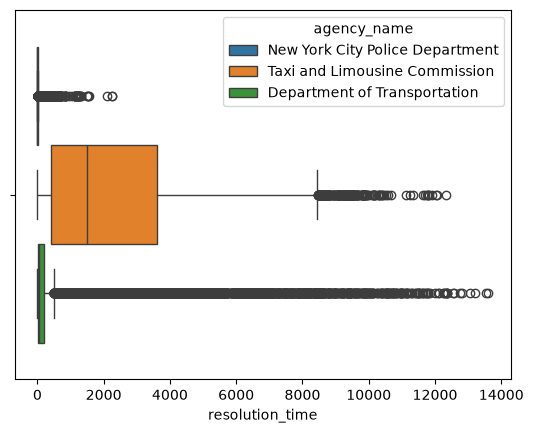

In [55]:
# plot time_resolution distributions

# _, axes = plt.subplots(nrows=1, ncols=4, figsize=(24, 6))

# all three as boxplot
sns.boxplot(data=agencies, x='resolution_time', hue='agency_name', showfliers=True, )
# axes[0].set(title='Time Resolution By Agency', xlabel='Time Resolution', ylabel='Agency')

plt.show()